# AR Model Notebook

1. **Setup** - Imports and helper functions
2. **Simulation 1** - Generating synthetic AR(1) data and checking stationarity
3. **Model 1: AR(1) on Synthetic Data** - Basically taken line-for-line from the Stan documentation
4. **Simulation 2** - Generating 5 series of AR(1) data that is generated from a CAR model as described in the Stan documentation.
5. **Model 2: Hierarchical AR (ICAR Prior) on Synthetic Data** - Fitting `ar_1_hierarchical_icar.stan`
6. **Load CTA Data for Stan** - Loading in data, adjacency matrix, etc.
7. **Model 3: Hierarchical AR (ICAR Prior) on CTA Data** - Fitting `ar_1_hierarchical_icar.stan`
8. **Model 4: Hierarchical AR (ICAR Prior) on CTA Data with Seasonality** - Fitting `ar_1_hier_icar_seas.stan`
9. **Posterior Predictive Checks** - Checking whether the estimated DGP fits the actual data

---
## 1. Setup

Imports and CmdStan path configuration.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from cmdstanpy import CmdStanModel, set_cmdstan_path
from cmdstanpy import from_csv
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

In [3]:
station_lookup = pd.read_csv("../../data/clean/station-lookup.csv")

def lookup_station(value, station_lookup):
    """Look up a CTA station by ID or name. Accepts a scalar or iterable."""
    id_to_name = dict(zip(station_lookup["station_id"], station_lookup["stationname"]))
    name_to_id = dict(zip(station_lookup["stationname"], station_lookup["station_id"]))
    
    def lookup_one(v):
        if isinstance(v, (int, np.integer)):
            return id_to_name.get(v)
        return name_to_id.get(v)
    
    # Scalar input
    if isinstance(value, (int, str, np.integer)):
        return lookup_one(value)
    
    # Iterable input (list, Series, array, etc.)
    return [lookup_one(v) for v in value]

In [4]:
def sim_ar_model(alpha, beta, sigma, T, initial=0, seed=None):
    np.random.seed(seed)
    assert T >= 1

    Y = np.zeros(T)
    epsilon = np.random.normal(0, sigma, size=T)

    Y[0] = initial

    for t in range(1, T):
        Y[t] = alpha + beta * Y[t - 1] + epsilon[t]
    return Y

## 2. Simulate AR(1) Data

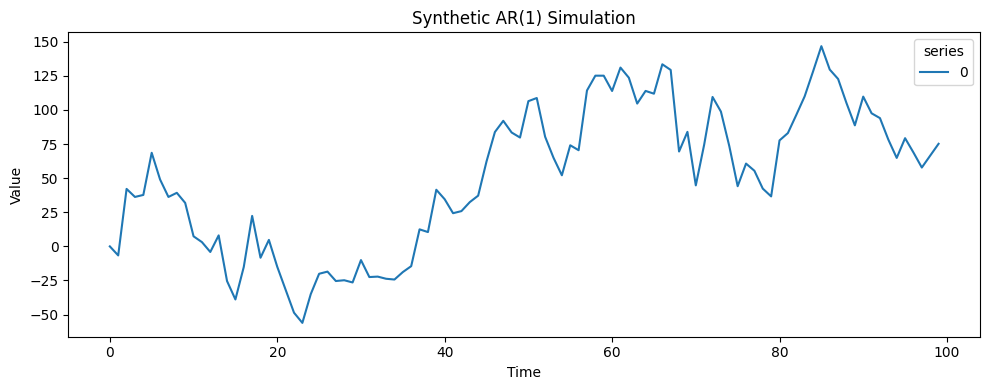

In [5]:
T = 100
alpha = 0
beta= 0.98
sigma = 20

y = sim_ar_model(alpha = alpha, beta = beta, sigma = 20, T = T, seed = 5)

df_sim = pd.DataFrame(y)
df_sim["t"] = range(T)
df_sim_long = df_sim.melt(id_vars="t", var_name="series", value_name="value")

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_sim_long, x="t", y="value", hue="series")
plt.title("Synthetic AR(1) Simulation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 3. Model 1: AR(1) on Simulated Data

In [6]:
stan_data_ar1_sim = {
    "T": T,
    "y": y
}

ar_mod = CmdStanModel(stan_file="ar_1.stan")
ar_mod_post = ar_mod.sample(data=stan_data_ar1_sim)
print(ar_mod_post.diagnose())

20:26:33 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

20:26:33 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### 3.1 Parameter Recovery

In [7]:
ar_mod_params = ar_mod_post.stan_variables()

print("True alpha:", alpha)
print("Estimated alpha:", ar_mod_params["alpha"].mean(axis=0))
print()
print("True sigma:", sigma)
print("Estimated sigma:", ar_mod_params["sigma"].mean(axis=0))
print()
print("True sigma:", sigma)
print("Estimated sigma:", ar_mod_params["sigma"].mean(axis=0))

True alpha: 0
Estimated alpha: 4.121858106797783

True sigma: 20
Estimated sigma: 18.992660614000002

True sigma: 20
Estimated sigma: 18.992660614000002


In [8]:
print(ar_mod_post.summary())

             Mean      MCSE    StdDev       MAD          5%         50%  \
lp__  -337.107000  0.029282  1.225980  1.000580 -339.442000 -336.775000   
alpha    4.121860  0.054940  2.689610  2.665770   -0.334417    4.155950   
beta     0.933633  0.000732  0.036153  0.035665    0.874568    0.933734   
sigma   18.992700  0.027115  1.356180  1.312570   16.889400   18.932400   

              95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__  -335.764000   1940.59   2365.16     5952.74  1.00204  
alpha    8.535760   2410.76   2503.33     7394.98  1.00165  
beta     0.993486   2451.84   2583.24     7520.98  1.00136  
sigma   21.361700   2542.48   2637.54     7799.03  1.00118  


## 4. Simulate Network AR(1) Data

In [14]:
def sim_ar_net_model(gamma, delta, c, beta, T, initial=None, seed=None):
    np.random.seed(seed)
    K = len(c)
    assert T >= 1

    # Simulate
    Y = np.zeros((T, K))
    if initial is not None:
        Y[0] = initial

    Sigma = np.zeros((K, K))
    for i in range(K):
        for j in range(K):
            if i == j:
                Sigma[i, j] = 1
            else:
                Sigma[i, j] = 0

    epsilon = np.random.multivariate_normal(np.zeros(K), Sigma, size=T)

    for t in range(1, T):
        Y[t] = gamma + delta * Y[t - 1] + c + beta * Y[t - 1] + epsilon[t]

    return Y

In [39]:
K = 5

# Simulation parameters
c_net = np.array([0.7, 0.05, 0.6, 0.12, 0.5])       # all node-level intercepts
beta_net = np.array([-0.18, -0.08, 0.01, 0.15, 0.34])   # all node-level coefficients
gamma_net = c_net.mean()                             # population intercept (hierarchical mean)
delta_net = beta_net.mean()                          # population AR coefficient (hierarchical mean)
T_net = 200

Y_net = sim_ar_net_model(
    gamma=gamma_net, delta=gamma_net,
    c=c_net, beta=beta_net, 
    T=T_net, seed=42
)

print(f"\nSimulated data shape: {Y_net.shape}")
print(f"\nPopulation intercept (gamma): {gamma_net}")
print(f"Population coefficient (delta): {delta_net}")


Simulated data shape: (200, 5)

Population intercept (gamma): 0.394
Population coefficient (delta): 0.048


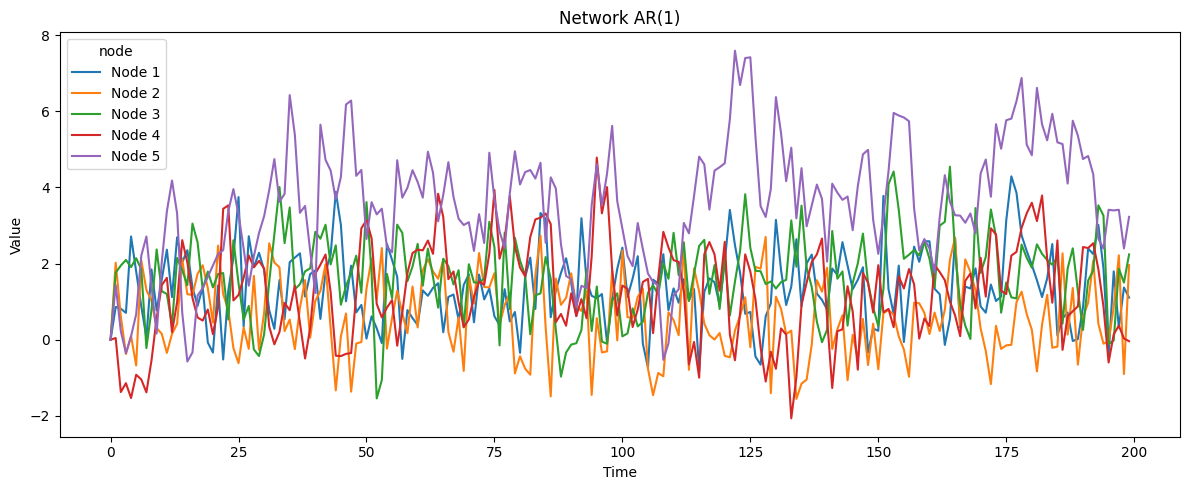

In [40]:
# Plot all 5 nodes
df_net = pd.DataFrame(Y_net, columns=[f"Node {i+1}" for i in range(K)])
df_net["t"] = range(T_net)
df_net_long = df_net.melt(id_vars="t", var_name="node", value_name="value")

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_net_long, x="t", y="value", hue="node")
plt.title("Network AR(1)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 4. Model 2: Hierarchical AR(1) with ICAR Prior on Simulated Network Data

In [44]:
node1 = []
node2 = []

W = np.zeros((K, K))
for i in range(K - 1):
    W[i, i + 1] = 1
    W[i + 1, i] = 1

for i in range(K):
    for j in range(i + 1, K):
        if W[i, j] == 1:
            node1.append(i + 1)
            node2.append(j + 1)

N_edges = len(node1)
print(f"Number of edges: {N_edges}")
print(f"Edge list: {list(zip(node1, node2))}")

stan_data_icar = {
    "T": T_net,
    "K": K,
    "Y": Y_net,
    "N_edges": N_edges,
    "node1": node1,
    "node2": node2
}

print(node1)
print(node2)

Number of edges: 4
Edge list: [(1, 2), (2, 3), (3, 4), (4, 5)]
[1, 2, 3, 4]
[2, 3, 4, 5]


In [45]:
ar_mod_icar = CmdStanModel(stan_file="ar_1_hierarchical_icar.stan")
ar_mod_icar_post = ar_mod_icar.sample(data=stan_data_icar)
print(ar_mod_icar_post.diagnose())

20:41:25 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

20:42:58 - cmdstanpy - INFO - CmdStan done processing.
20:42:58 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Location parameter[1] is -nan, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf


Checking sampler transitions treedepth.
1794 of 4000 (44.85%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



### 4.1 Parameter Recovery

In [46]:
ar_mod_icar_params = ar_mod_icar_post.stan_variables()

print("=== Population Level ===")
print("True gamma (pop intercept):", gamma_net)
print("Estimated gamma:", ar_mod_icar_params["gamma"].mean(axis=0))
print()
print("True delta (pop coefficient):", delta_net)
print("Estimated delta:", ar_mod_icar_params["delta"].mean(axis=0))
print()
print("=== Node Level ===")
print("True c (node intercepts):", c_net)
print("Estimated c:", ar_mod_icar_params["c"].mean(axis=0))
print()
print("True beta (node coefficients):", beta_net)
print("Estimated beta:", ar_mod_icar_params["beta"].mean(axis=0))
print()
print("=== Innovation SD ===")
print("True sigma (diag of Sigma):", np.sqrt(np.diag(Sigma_net)))
print("Estimated sigma:", ar_mod_icar_params["sigma"].mean(axis=0))

=== Population Level ===
True gamma (pop intercept): 0.394
Estimated gamma: 0.7328401193361501

True delta (pop coefficient): 0.048
Estimated delta: 0.46073797332000005

=== Node Level ===
True c (node intercepts): [0.7  0.05 0.6  0.12 0.5 ]
Estimated c: [0.97107321 0.49332077 0.96011676 0.47572704 0.87135742]

True beta (node coefficients): [-0.18 -0.08  0.01  0.15  0.34]
Estimated beta: [0.28264168 0.21703627 0.41314443 0.63342661 0.75747026]

=== Innovation SD ===


NameError: name 'Sigma_net' is not defined

In [32]:
print(ar_mod_icar_post.summary())

                   Mean      MCSE    StdDev       MAD          5%         50%  \
lp__        -584.066000  0.112066  3.642400  3.613520 -590.570000 -583.703000   
gamma          1.330990  0.006130  0.241473  0.196841    0.944358    1.343260   
c_zero[1]     -0.940681  0.015459  0.661123  0.656614   -2.072470   -0.907740   
c_zero[2]     -0.119889  0.011750  0.545056  0.535209   -1.029500   -0.114413   
c_zero[3]      0.963831  0.011982  0.623352  0.608666    0.016921    0.916635   
c_zero[4]      0.766548  0.012198  0.633693  0.617292   -0.254633    0.763139   
c_zero[5]     -0.100122  0.012223  0.600619  0.589658   -1.127050   -0.092689   
sigma_c        0.462166  0.006335  0.245383  0.184935    0.183679    0.403717   
delta          0.498496  0.000351  0.027030  0.027349    0.454224    0.498842   
phi_zero[1]   -1.314720  0.015697  0.630510  0.593711   -2.474920   -1.228660   
phi_zero[2]   -0.823922  0.011292  0.472184  0.447281   -1.699790   -0.761425   
phi_zero[3]   -0.003350  0.0

## 5. Load CTA Data for Stan

In [4]:
# Read cleaned data
cta_wide = pd.read_csv("../../data/clean/cta-data-wide.csv")
cta_adj = pd.read_csv("../../data/clean/cta-adjacency.csv")

# Extract Y matrix (station columns only)
station_cols = [c for c in cta_wide.columns if c.startswith("s_")]
Y_cta = cta_wide[station_cols].values

T_cta = Y_cta.shape[0]
K_cta = Y_cta.shape[1]

In [5]:
# Build edge list from adjacency matrix (1-indexed for Stan)
adj_ids = cta_adj["station_id"].astype(str).values
W_cta = cta_adj.drop(columns="station_id").values

node1_cta = []
node2_cta = []
for i in range(K_cta):
    for j in range(i + 1, K_cta):
        if W_cta[i, j] == 1:
            node1_cta.append(i + 1)
            node2_cta.append(j + 1)

N_edges_cta = len(node1_cta)

In [6]:
stan_data_cta = {
    "T": T_cta,
    "K": K_cta,
    "Y": Y_cta,
    "N_edges": N_edges_cta,
    "node1": node1_cta,
    "node2": node2_cta,
}

print(f"Y shape: {T_cta} weeks x {K_cta} stations")
print(f"Edges: {N_edges_cta}")
print(f"NAs in Y: {np.isnan(Y_cta).sum()}")

Y shape: 208 weeks x 138 stations
Edges: 142
NAs in Y: 0


## 6. Model 3: CTA data on AR(1) Hierarchical ICAR Model

In [10]:
ar_mod_cta_icar = CmdStanModel(stan_file="ar_1_hierarchical_icar.stan")
ar_mod_cta_icar_post = ar_mod_cta_icar.sample(data=stan_data_cta)
print(ar_mod_cta_icar_post.diagnose())

#ar_mod_cta_icar_post.save_csvfiles(dir='./ar_mod_cta_icar_output')

00:22:14 - cmdstanpy - INFO - compiling stan file /deac/sta/classes/sta720-sp-2026/hatan25/sta720-project/notebooks/ar/ar_1_hierarchical_icar.stan to exe file /deac/sta/classes/sta720-sp-2026/hatan25/sta720-project/notebooks/ar/ar_1_hierarchical_icar
00:22:37 - cmdstanpy - INFO - compiled model executable: /deac/sta/classes/sta720-sp-2026/hatan25/sta720-project/notebooks/ar/ar_1_hierarchical_icar
00:22:37 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

00:38:15 - cmdstanpy - INFO - CmdStan done processing.
00:38:15 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Consider re-running with show_console=True if the above output is unclear!



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [4]:
ar_mod_cta_icar_post = from_csv('./ar_mod_cta_icar_output')

In [5]:
draws = ar_mod_cta_icar_post.stan_variables()
draws_df = ar_mod_cta_icar_post.draws_pd()
draws_array = ar_mod_cta_icar_post.draws()

gamma = draws['gamma']
delta = draws['delta']
sigma_phi = draws['sigma_phi']

print(f"gamma: {gamma.mean():.3f} [{np.quantile(gamma, 0.05):.3f}, {np.quantile(gamma, 0.95):.3f}]")
print(f"delta: {delta.mean():.3f} [{np.quantile(delta, 0.05):.3f}, {np.quantile(delta, 0.95):.3f}]")
print(f"sigma_phi: {sigma_phi.mean():.3f} [{np.quantile(sigma_phi, 0.05):.3f}, {np.quantile(sigma_phi, 0.95):.3f}]")

gamma: 0.003 [0.002, 0.004]
delta: -0.262 [-0.272, -0.253]
sigma_phi: 0.085 [0.070, 0.102]


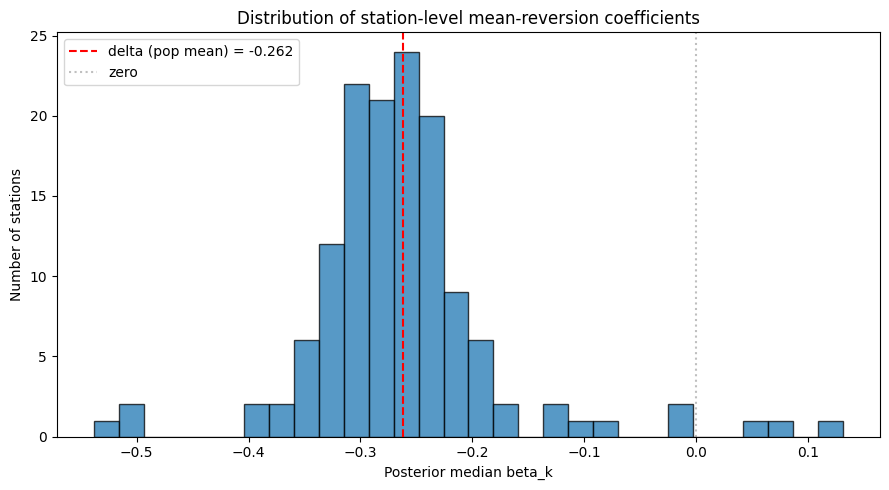

In [6]:
beta = draws['beta']                    # shape: (n_draws, K)
beta_median = np.median(beta, axis=0)   # shape: (K,)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(beta_median, bins=30, edgecolor='black', alpha=0.75)

# Reference lines for the population mean and zero
delta_median = np.median(draws['delta'])
ax.axvline(delta_median, color='red', linestyle='--', label=f'delta (pop mean) = {delta_median:.3f}')
ax.axvline(0, color='gray', linestyle=':', alpha=0.5, label='zero')

ax.set_xlabel('Posterior median beta_k')
ax.set_ylabel('Number of stations')
ax.set_title('Distribution of station-level mean-reversion coefficients')
ax.legend()
plt.tight_layout()
plt.show()

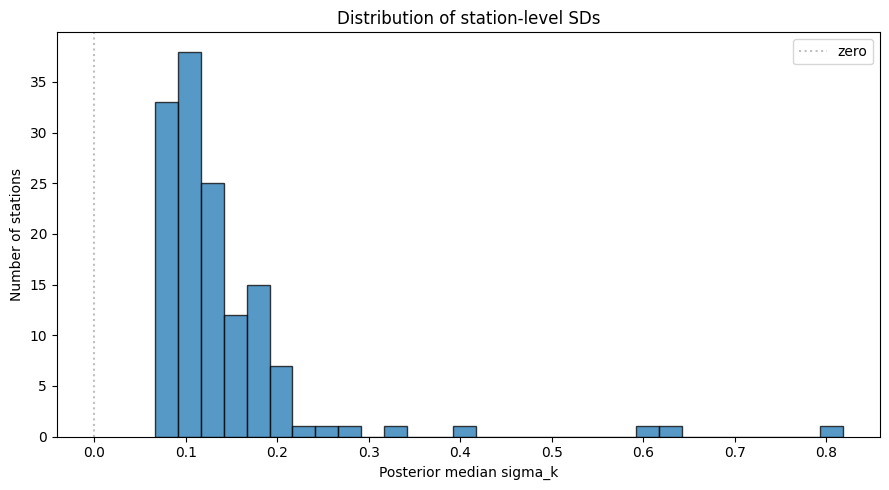

In [15]:
sigma = draws['sigma']                    # shape: (n_draws, K)
sigma_median = np.median(sigma, axis=0)   # shape: (K,)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sigma_median, bins=30, edgecolor='black', alpha=0.75)

# Reference lines for the population mean and zero
delta_median = np.median(draws['delta'])
ax.axvline(0, color='gray', linestyle=':', alpha=0.5, label='zero')

ax.set_xlabel('Posterior median sigma_k')
ax.set_ylabel('Number of stations')
ax.set_title('Distribution of station-level SDs')
ax.legend()
plt.tight_layout()
plt.show()

In [53]:
station_id = cta_adj["station_id"]

station_df = pd.concat([station_id, pd.Series(beta_median, name='beta_median'), pd.Series(sigma_median, name='sigma_median')], axis=1)
print(station_df)

station_select = station_df.loc[(station_df['beta_median'] < -0.325) & (station_df['beta_median'] > -0.45)]["station_id"]
print(station_select)

lookup_station(station_select, station_lookup)

     station_id  beta_median  sigma_median
0         40010    -0.288313      0.112092
1         40020    -0.257758      0.083607
2         40030    -0.309658      0.081971
3         40040    -0.308145      0.172978
4         40050    -0.203668      0.104096
..          ...          ...           ...
133       41660    -0.288354      0.102721
134       41670    -0.316079      0.087973
135       41680    -0.020275      0.326886
136       41690    -0.286795      0.269500
137       41700    -0.239648      0.097355

[138 rows x 3 columns]
7      40080
11     40130
13     40150
21     40240
24     40280
35     40420
38     40450
41     40480
52     40600
60     40700
81     40930
82     40960
94     41080
107    41230
109    41250
111    41270
125    41430
Name: station_id, dtype: int64


['Sheridan',
 '51st',
 'Pulaski-Cermak',
 '79th',
 'Central-Lake',
 'Cicero-Cermak',
 '95th/Dan Ryan',
 'Cicero-Lake',
 'Kostner',
 'Laramie',
 'Midway Airport',
 'Pulaski-Orange',
 '47th-South Elevated',
 '47th-Dan Ryan',
 'Central-Evanston',
 '43rd',
 '87th']

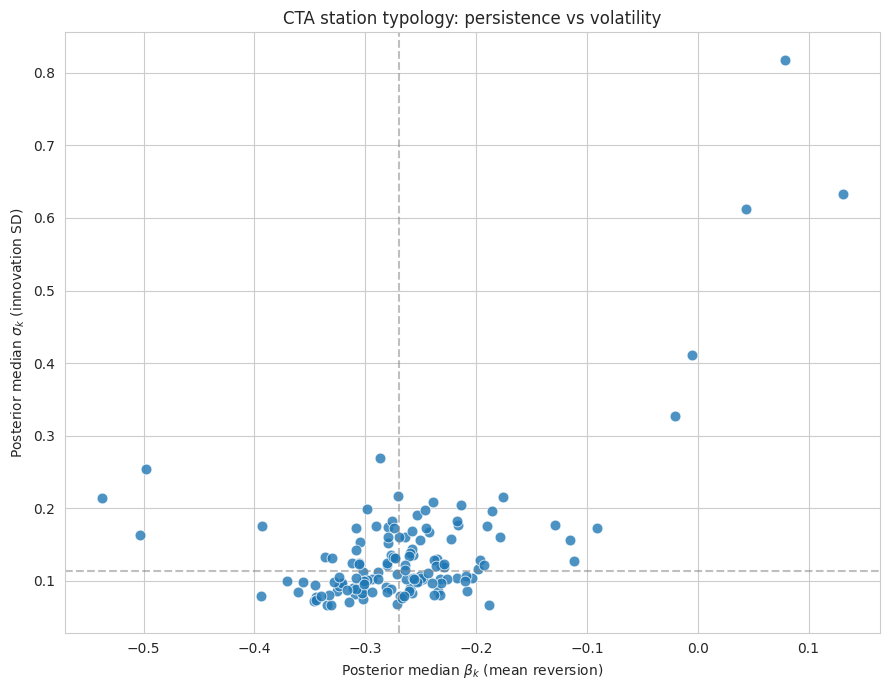

In [56]:
# Plot
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=station_df,
    x='beta_median',
    y='sigma_median',
    s=60,
    alpha=0.8,
    ax=ax,
)

# Quadrant lines at the medians
ax.axvline(station_df['beta_median'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(station_df['sigma_median'].median(), color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel(r'Posterior median $\beta_k$ (mean reversion)')
ax.set_ylabel(r'Posterior median $\sigma_k$ (innovation SD)')
ax.set_title('CTA station typology: persistence vs volatility')

plt.tight_layout()
plt.show()

## 7. Model 4: CTA data on AR(1) Hierarchical ICAR Model with Seasonality

In [71]:
seas_cols = [c for c in cta_wide.columns if c.startswith("mon")]
X_cta = cta_wide[seas_cols].values

P_cta = X_cta.shape[1]

In [76]:
stan_data_cta_seas = {
    "T": T_cta,
    "K": K_cta,
    "Y": Y_cta,
    "P": P_cta,
    "X": X_cta,
    "N_edges": N_edges_cta,
    "node1": node1_cta,
    "node2": node2_cta,
}

print(f"Y shape: {T_cta} weeks x {K_cta} stations")
print(f"X shape: {T_cta} weeks x {P_cta} month dummy variables")
print(f"Edges: {N_edges_cta}")
print(f"NAs in Y: {np.isnan(Y_cta).sum()}")

Y shape: 208 weeks x 138 stations
X shape: 208 weeks x 11 month dummy variables
Edges: 142
NAs in Y: 0
142


In [80]:
#ar_mod_cta_icar_seas = CmdStanModel(stan_file="ar_1_hier_icar_seas.stan")
#mod_final = ar_mod_cta_icar_seas.sample(data=stan_data_cta_seas)
#mod_final.save_csvfiles(dir='./ar_mod_cta_icar_seas_output')

In [82]:
ar_mod_final = from_csv('./ar_mod_cta_icar_seas_output')
print(ar_mod_final.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [83]:
draws = ar_mod_final.stan_variables()
draws_df = ar_mod_final.draws_pd()
draws_array = ar_mod_final.draws()

gamma = draws['gamma']
delta = draws['delta']
sigma_phi = draws['sigma_phi']

print(f"gamma: {gamma.mean():.3f} [{np.quantile(gamma, 0.05):.3f}, {np.quantile(gamma, 0.95):.3f}]")
print(f"delta: {delta.mean():.3f} [{np.quantile(delta, 0.05):.3f}, {np.quantile(delta, 0.95):.3f}]")
print(f"sigma_phi: {sigma_phi.mean():.3f} [{np.quantile(sigma_phi, 0.05):.3f}, {np.quantile(sigma_phi, 0.95):.3f}]")

gamma: 0.064 [0.061, 0.068]
delta: -0.340 [-0.349, -0.330]
sigma_phi: 0.089 [0.074, 0.105]


In [86]:
seas = draws['seas']
print("Posterior medians:")
for i, m in enumerate(np.median(seas, axis=0)):
    print(f"  Month {i+2}: {m:+.3f}")  # Feb=2 through Dec=12 if January is baseline

Posterior medians:
  Month 2: -0.034
  Month 3: -0.055
  Month 4: -0.044
  Month 5: -0.052
  Month 6: -0.052
  Month 7: -0.042
  Month 8: -0.063
  Month 9: -0.049
  Month 10: -0.075
  Month 11: -0.113
  Month 12: -0.151


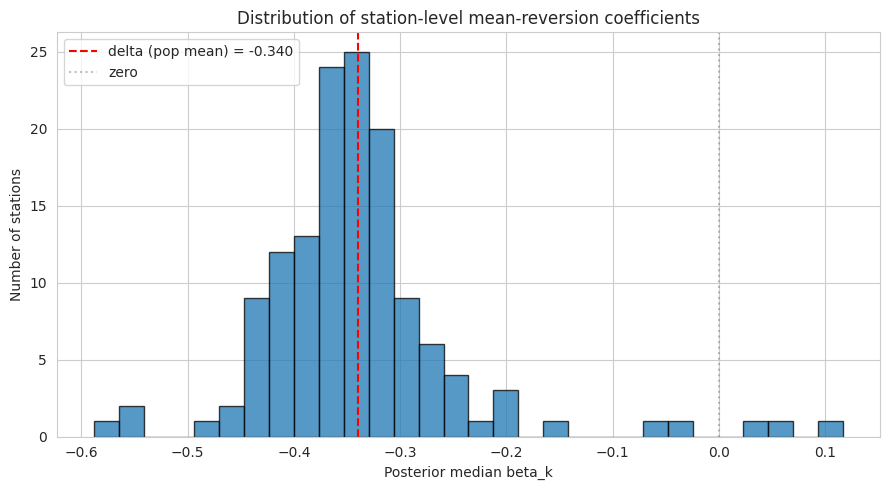

In [87]:
beta = draws['beta']                    # shape: (n_draws, K)
beta_median = np.median(beta, axis=0)   # shape: (K,)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(beta_median, bins=30, edgecolor='black', alpha=0.75)

# Reference lines for the population mean and zero
delta_median = np.median(draws['delta'])
ax.axvline(delta_median, color='red', linestyle='--', label=f'delta (pop mean) = {delta_median:.3f}')
ax.axvline(0, color='gray', linestyle=':', alpha=0.5, label='zero')

ax.set_xlabel('Posterior median beta_k')
ax.set_ylabel('Number of stations')
ax.set_title('Distribution of station-level mean-reversion coefficients')
ax.legend()
plt.tight_layout()
plt.show()

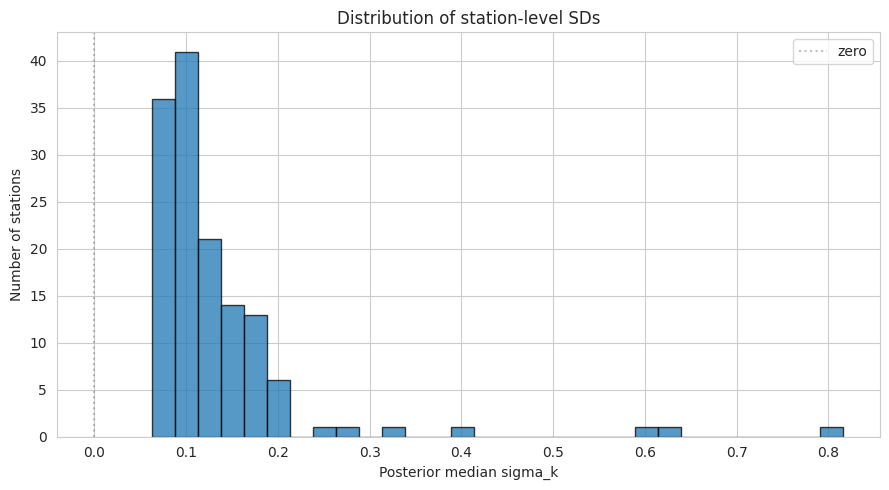

In [88]:
sigma = draws['sigma']                    # shape: (n_draws, K)
sigma_median = np.median(sigma, axis=0)   # shape: (K,)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(sigma_median, bins=30, edgecolor='black', alpha=0.75)

# Reference lines for the population mean and zero
delta_median = np.median(draws['delta'])
ax.axvline(0, color='gray', linestyle=':', alpha=0.5, label='zero')

ax.set_xlabel('Posterior median sigma_k')
ax.set_ylabel('Number of stations')
ax.set_title('Distribution of station-level SDs')
ax.legend()
plt.tight_layout()
plt.show()

In [96]:
station_df = pd.concat([station_id, pd.Series(beta_median, name='beta_median'), pd.Series(sigma_median, name='sigma_median')], axis=1)
print(station_df)

station_select = station_df.loc[(station_df['beta_median'] < -.2) & (station_df['beta_median'] > -0.25)]["station_id"]
print(station_select)

lookup_station(station_select, station_lookup)

     station_id  beta_median  sigma_median
0         40010    -0.362860      0.105291
1         40020    -0.363188      0.076830
2         40030    -0.391175      0.079425
3         40040    -0.368890      0.163800
4         40050    -0.317743      0.096181
..          ...          ...           ...
133       41660    -0.368724      0.096712
134       41670    -0.387806      0.087507
135       41680    -0.070741      0.325310
136       41690    -0.324270      0.265913
137       41700    -0.303402      0.092123

[138 rows x 3 columns]
6      40070
34     40400
44     40520
66     40760
114    41300
130    41490
Name: station_id, dtype: int64


['Jackson/Dearborn', 'Noyes', 'Foster', 'Granville', 'Loyola', 'Harrison']

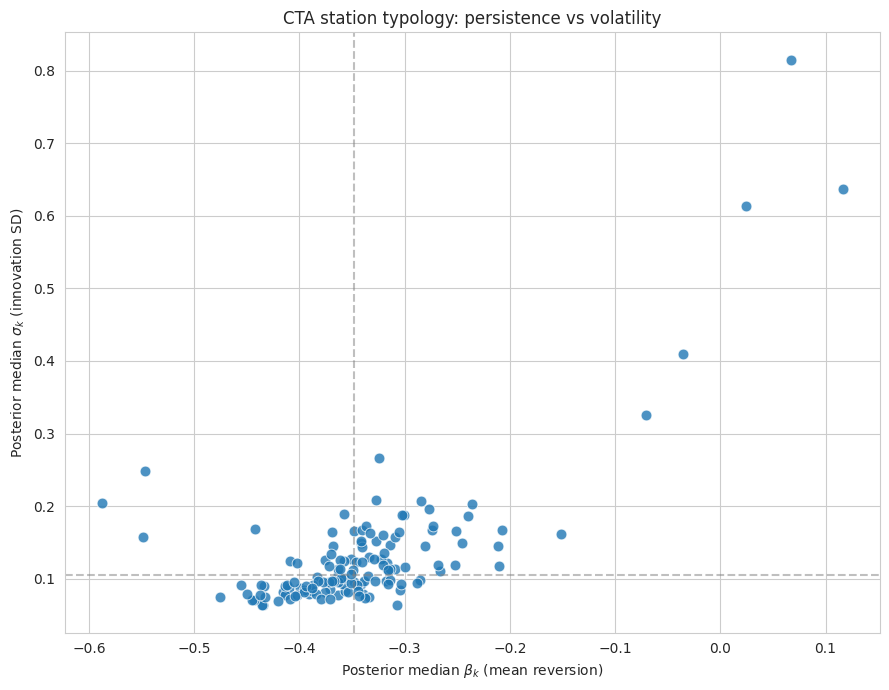

In [97]:
# Plot
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(9, 7))

sns.scatterplot(
    data=station_df,
    x='beta_median',
    y='sigma_median',
    s=60,
    alpha=0.8,
    ax=ax,
)

# Quadrant lines at the medians
ax.axvline(station_df['beta_median'].median(), color='gray', linestyle='--', alpha=0.5)
ax.axhline(station_df['sigma_median'].median(), color='gray', linestyle='--', alpha=0.5)

ax.set_xlabel(r'Posterior median $\beta_k$ (mean reversion)')
ax.set_ylabel(r'Posterior median $\sigma_k$ (innovation SD)')
ax.set_title('CTA station typology: persistence vs volatility')

plt.tight_layout()
plt.show()

## 9. Posterior Predictive Checks

In [14]:
station_select = ['Sox-35th-Dan Ryan', 'Clark/Lake', 'Loyola', 'UIC-Halsted']
station_select_id = lookup_station(station_select, station_lookup)
print(station_select_id)

check_idx = (station_lookup[station_lookup['station_id'].isin(station_select_id)].index + 1).tolist()
print(check_idx)

[40190, 40380, 41300, 40350]
[19, 35, 38, 123]


In [110]:
gq_data = {
    "T": T_cta,
    "K": K_cta,
    "Y": Y_cta,
    "P": P_cta,
    "X": X_cta,
    "N_edges": N_edges_cta,
    "node1": node1_cta,
    "node2": node2_cta,
    "N_check": len(check_idx),
    "check_idx": check_idx
}

gq_model = CmdStanModel(stan_file='generate_quantities.stan')
gq_fit = gq_model.generate_quantities(data=gq_data, previous_fit=ar_mod_final)
y_rep = gq_fit.stan_variables()['y_rep']

12:18:11 - cmdstanpy - INFO - Chain [1] start processing
12:18:11 - cmdstanpy - INFO - Chain [2] start processing
12:18:11 - cmdstanpy - INFO - Chain [3] start processing
12:18:11 - cmdstanpy - INFO - Chain [4] start processing
12:18:12 - cmdstanpy - INFO - Chain [1] done processing
12:18:13 - cmdstanpy - INFO - Chain [3] done processing
12:18:13 - cmdstanpy - INFO - Chain [2] done processing
12:18:13 - cmdstanpy - INFO - Chain [4] done processing


In [134]:
# Build a long-format dataframe with everything ggplot needs
ppc_records = []
for i, station in enumerate(station_select):
    k = check_idx[i] - 1
    median = np.median(y_rep[:, :, i], axis=0)
    lower = np.quantile(y_rep[:, :, i], 0.05, axis=0)
    upper = np.quantile(y_rep[:, :, i], 0.95, axis=0)
    observed = Y_cta[:, k]
    
    for t in range(T_cta):
        ppc_records.append({
            'station': station,
            'week': t,
            'observed': observed[t],
            'median': median[t],
            'lower': lower[t],
            'upper': upper[t],
        })

ppc_df = pd.DataFrame(ppc_records)
ppc_df.to_csv('ar_mod_cta_icar_seas_output/ppc_summary.csv', index=False)

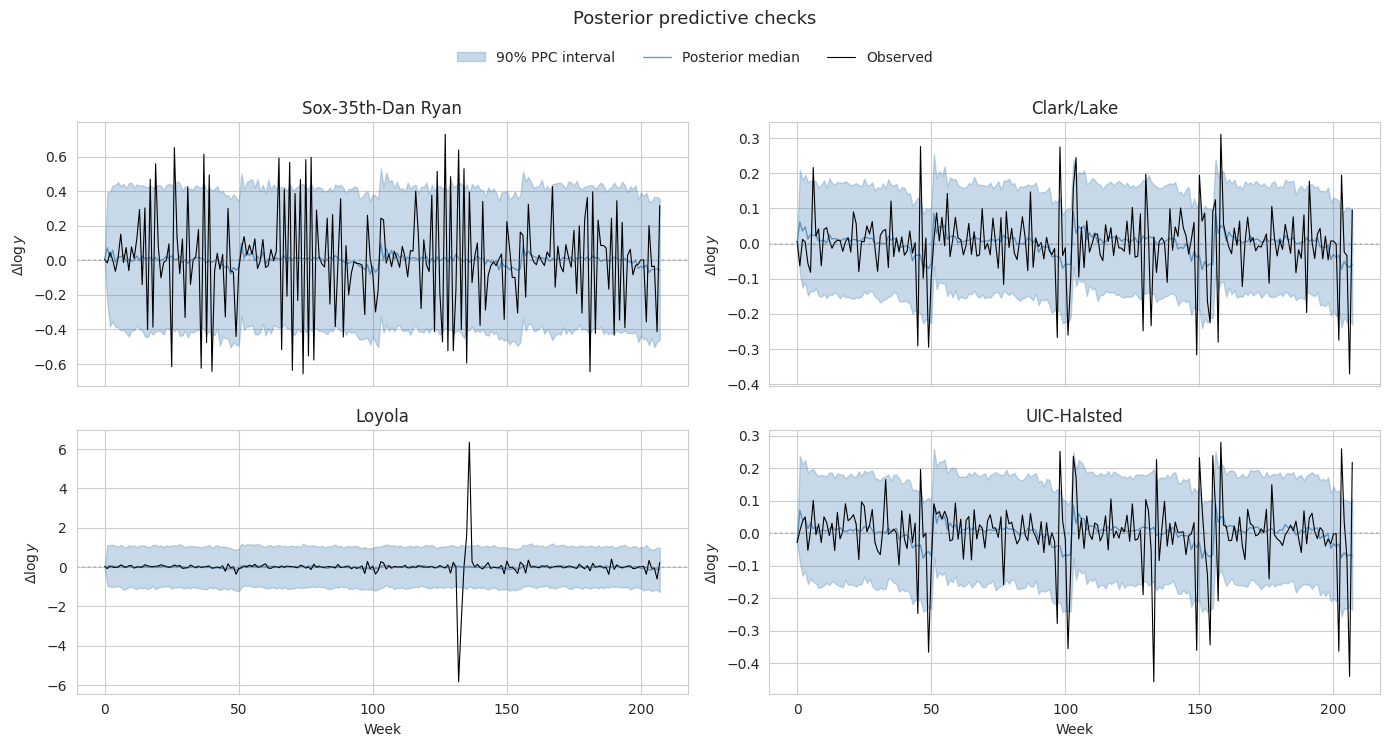

In [133]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
axes = axes.flatten()

handles, labels = None, None

for i in range(len(station_select)):
    ax = axes[i]
    k = check_idx[i] - 1

    # Compute intervals across draws
    median = np.median(y_rep[:, :, i], axis=0)
    lower = np.quantile(y_rep[:, :, i], 0.05, axis=0)
    upper = np.quantile(y_rep[:, :, i], 0.95, axis=0)

    ax.fill_between(range(T_cta), lower, upper, alpha=0.3, color='steelblue', label='90% PPC interval')
    ax.plot(median, color='steelblue', linewidth=1, alpha=0.8, label='Posterior median')
    ax.plot(Y_cta[:, k], color='black', linewidth=0.8, label='Observed')

    ax.axhline(0, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(station_select[i])
    ax.set_ylabel(r'$\Delta \log y$')

    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

# X-labels only on bottom row
axes[2].set_xlabel('Week')
axes[3].set_xlabel('Week')

# Shared legend
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)

fig.suptitle('Posterior predictive checks', y=1.06, fontsize=13)
plt.tight_layout()
plt.show()